# Trucs et astuces plus avancés en numpy

Rechercher des valeurs et sélectionner des portions de matrices est un exercice récurrent en sciences des données. Apprenons à le faire de différentes manières.

**Exercices** (marqués <span style="color:red"> EXO</span>) Des exercices sont proposés régulièrement dans le notebook pour éviter *l'effet contemplatif* des exemples. Si vous maitrisez déjà les concepts de base et que les solutions vous semblent évidentes, n'héstiez pas à sauter des questions.

Tous les exercices sont classés par ordre d'importance:  <span style="color:red"> 1</span>="essentiel", <span style="color:red">2</span>="utile, <span style="color:red">3</span>="optionnel et/ou avancé"

In [1]:
import numpy as np

In [18]:
a = np.random.randn(100,2)
#print(a)
# element de la matrice complète < 0.5
index = np.where(a<0.5) # retourne les indices dans (I,J)
                        # I: indice des lignes
                        # J: indice des colonnes
#print(index)
# recherche dans une colonne
index2 = np.where(a[:,0]<0.5)
print(index2)

# ajouter des print pour comprendre les entrées/sorties!

(array([ 0,  2,  3,  4,  5,  6,  7, 10, 12, 13, 14, 16, 18, 20, 21, 22, 23,
       25, 26, 27, 30, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 44, 45, 46,
       48, 49, 50, 51, 53, 54, 56, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 81, 82, 85, 86, 88, 90, 91, 93,
       95, 96, 97]),)


**Attention au type de retour**

Le type de `index` est sans surprise... Mais celui de `index2` est plus déroutant: il s'agit d'un tuple mais avec un seul champ rempli...
Pour utiliser les indices extraits facilement, il faut donc faire:

In [19]:
index2, = np.where(a[:,0]<0.5) # on ne s'intéresse qu'au premier membre retourné!
# a[index2,:] = ...

## Fonction de recherche en syntaxe légère


In [24]:
y = np.array([-1, -1, -1, 1, 1, 1])
x = np.random.rand(6,2)

print(y==-1)

# sélection des 3 premières lignes de x
print(x)
print(y)
print(x[y==-1])


# contraintes logiques: 
#    - x et y doivent avoir la même taille
#    - y doit être un vecteur

# sélection des lignes de x qui commencent par un nombre > 0.5
#print(x[x[:,0]>0.5])


[ True  True  True False False False]
[[0.03341498 0.43972437]
 [0.76814881 0.9586776 ]
 [0.26359155 0.77958874]
 [0.85552755 0.64786475]
 [0.05054527 0.93533594]
 [0.94951412 0.58892001]]
[-1 -1 -1  1  1  1]
[[0.03341498 0.43972437]
 [0.76814881 0.9586776 ]
 [0.26359155 0.77958874]]


## Transformation de matrice

`np.where` permet de renvoyer une matrice transformée en ajoutant des arguments dans la méthode

> `np.where(m > alpha, retour_si_vrai, retour_si_faux)`

On peut se servir de cette syntaxe pour faire des comptages

In [31]:
a = np.random.randn(5,2)
# Mettre à zeros tous les éléments négatifs:
b = np.where(a<0., 0., a)    # (clause, TODO if true, TODO if false)
c = np.where(a<0., -1., 1.)  # Extraire le signe des éléments de a
print(a)
print('\n')
print(b)
print('\n')
print(c)
print('\n')

nb_elem_pos = np.where(a>0., 1, 0).sum() # construction d'une matrice binaire + somme = comptage
print(nb_elem_pos)


[[ 1.70605744 -0.19974176]
 [ 0.45169728 -1.1037562 ]
 [-0.53903412  1.04489635]
 [ 0.71274267  0.02802943]
 [ 0.28458429  0.09079916]]


[[1.70605744 0.        ]
 [0.45169728 0.        ]
 [0.         1.04489635]
 [0.71274267 0.02802943]
 [0.28458429 0.09079916]]


[[ 1. -1.]
 [ 1. -1.]
 [-1.  1.]
 [ 1.  1.]
 [ 1.  1.]]


7


## ATTENTION aux doubles clauses

il y a un piège dans la priorité donnée aux opérations: il faut ajouter des parenthèses

In [32]:
# pour l'estimation d'une loi jointe entre a et b
N = 100
a = np.ceil(np.random.rand(N) * 10)   # entre 1 et 10
b = np.round(np.random.rand(N))       # 0 ou 1
np.where((a == 4) & (b==0), 1., 0.)   # OK
# np.where( a == 4  &  b==0 , 1., 0.) # KO !!! => le & est prioritaire sur le == !!!

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

# <span style="color:red"> EXO(3) Exercice basique </span>

Générer 1000 tirages selon une loi normale centrée réduite
 - Vérifier par comptage que la moitié (environ) des tirages est supérieure à 0
 - Vérifier que (environ) 2/3 des tirages sont compris entre entre moins l'écart-type et plus l'écart type

In [51]:
#  TODO 
C, S = 0, 0
for _ in range(10):
    N = 1000
    a = np.random.randn(1000)
    c = np.sum( np.where(a >= 0, 1, 0) )/10
    s = np.sum( np.where( (-1 < a) & (a < 1), 1, 0) )/10
    C += c
    S += s
print(C / 10)
print(S / 10)

49.690000000000005
68.36999999999999


# <span style="color:red"> EXO(1) Comptage des erreurs </span>

Soit $\mathbf y\in \{0,1\}^n$ les étiquettes associées à $n$ données et $\mathbf yhat\in \{0,1\}^n$ les sorties de votre modèle, calculer le taux de bonne classification de votre approche.

$$Y = \begin{pmatrix} y_0\\ \vdots \\ y_n \end{pmatrix} \qquad  \hat Y = \begin{pmatrix} \hat y_0\\ \vdots \\\hat y_n \end{pmatrix} \Rightarrow \text{Combien de valeurs en commun dans les deux vecteurs?}
                 $$


Note: avant de chercher la réponse à la question, essayer de bien comprendre comment ont été générées les données, les appels de fonction ne sont pas triviaux.

In [62]:
# generation arbitraire des données et des sorties
n = 100
y = np.ones(n)
y[:n//2] = 0

yhat = y.copy()
yhat = np.where(np.random.random(n)<0.1, 1-yhat, yhat) # corruption de y par une bernoulli de paramètre 0.1

# calculer le taux de bonne classification

#  TODO 
Class = np.where( y == yhat, 1, 0)
print(np.sum(Class) / n * 100)

90.0


# <span style="color:red"> EXO(2) Comptage des erreurs bis [sorties d'un modèle probabiliste]</span>

Soit $\mathbf y\in \{0,1,2\}^n$ les étiquettes de 3 classes associées à $n$ données et $\mathbf p\in [0,1]^{n\times 3}$ les sorties de votre modèle probabiliste donnant la probabilité d'appartenance à chaque classe pour chaque individu, calculer le taux de bonne classification de votre approche.

$$Y = \begin{pmatrix} y_0\\ \vdots \\ y_n \end{pmatrix} \qquad  P = \begin{pmatrix}  P(y=0 | X=x_0) & P(y=1 | X=x_0) & P(y=2 | X=x_0)\\ \vdots \\ P(y=0 | X=x_n) & P(y=1 | X=x_n) & P(y=2 | X=x_n) \end{pmatrix}
                 $$


Note: avant de chercher la réponse à la question, essayer de bien comprendre comment ont été générées les données, les appels de fonction ne sont pas triviaux.

In [101]:
n = 100
y = np.random.randint(0,3,(n))

p = np.random.rand(n,3)                     # p est yhat
for i in range(len(p)): p[i,y[i]] += 0.5    # len(p) = n
p /= p.sum(1).reshape(-1,1)

#print(y[:10]) # affichage des 10 premiers y
#print(p[:10])


#  TODO 
y = y.reshape(-1,1)                         # on formate y pour avoir un vecteur colonne
yhat = np.argmax(p,1).reshape(-1,1)         # on compare si y == yhat (yhat adapté pour obtenir un vecteur colonne qui contient la position du max de chaque ligne)
taux = [y == yhat]                              # ici ca tombe bien car index colonne = "valeur", sinon il aurait fallu le convertir (par exemple 0 == a, 1 == b ... dict.get() ?)
                                                    
print(np.sum(taux)/n*100, "% de bonne estimation")

dict = {0 : 'a', 1 : 'b', 2 : 'c'}          # S'il y a besoin de transformer les indices de colonnes en autre chose, cette technique fonctionne, compléxité linéaire
def trad(nbr):
    return dict.get(nbr)

trad_vect = np.vectorize(trad)
yhat_alph = trad_vect(yhat)

#print(yhat_alph)


81.0 % de bonne estimation


# <span style="color:red"> EXO(1) Statistiques par classes </span>

Soit des données classiques en machine learning associant $n$ observations en 2 dimensions $X$ et une supervision $Y$ indiquant la classe de chaque point:

$$X = \begin{pmatrix}
                x_{0,0}& x_{0,1} \\
                \vdots & \vdots\\
                x_{n,0} & x_{n,1} 
                \end{pmatrix}, \qquad  Y = \begin{pmatrix} y_0\\ \vdots \\ y_n \end{pmatrix}
                 $$

Ces données sont représentées sur la figure ci-dessous (chaque ligne de la matrice $X$ correspond à un point de la figure):

<img src="ressources/gauss.png">

La boite suivante permet de charger les données, vous répondrez ensuite aux questions suivantes:

1. Compter les données
1. Quels sont les codes utilisés pour les deux classes?
1. Quelles sont les moyennes de chacune des deux classes (sans boucle `for`)?
1. Quelles sont les valeurs mini et maxi sur chaque dimension de chacune des deux classes (toujours sans boucle `for`)?

In [140]:
import pickle as pkl
# récupération des données:
data = pkl.load(open("ressources/gauss.pkl", "rb"))

X,Y= data['X'],data['Y']

#  TODO 
n = X.shape[0]                                      # 1) On a n données


#  TODO
#print(X)
#print(np.unique(Y))                                # 2) Les classes sont 1 ou 0


#  TODO
# Pas top
moy_0 = [ np.mean( X[ np.where( Y == 0 ),: ], 1 ) ]  
moy_1 = [ np.mean( X[ np.where( Y == 1 ),: ], 1 ) ]

## plutot faire
moy_0 = X[Y == 0].mean(0)                           # 3) moyenne du paramètre 1 et 2 pour les X de échantillons de classe 0
moy_1 = X[Y == 1].mean(0)

#print(moy_0, moy_1)


#  TODO
min_0 = np.min( X[ Y == 0], 0)
min_1 = np.min( X[ Y == 1], 0)
max_0 = np.max( X[ Y == 0], 0)
max_1 = np.max( X[ Y == 1], 0)


print(min_0, min_1, max_0, max_1)

[-3.65006582 -4.16355031] [-0.29702231 -0.28858126] [0.85031483 1.31779297] [5.6005963  4.45727817]


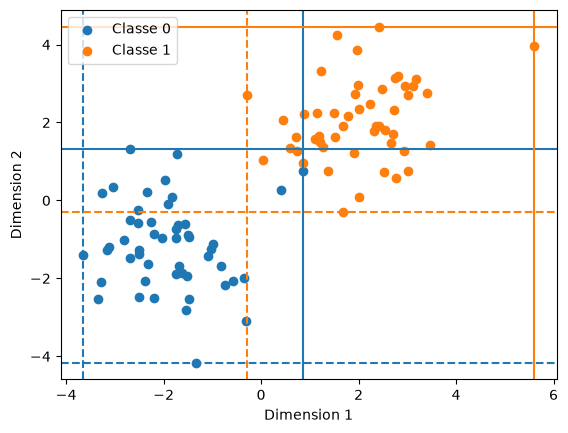

In [ ]:
import matplotlib.pyplot as plt             # made by IA

p0 = plt.scatter(X[Y == 0, 0], X[Y == 0, 1], label="Classe 0")
p1 = plt.scatter(X[Y == 1, 0], X[Y == 1, 1], label="Classe 1")

c0 = p0.get_facecolor()[0]
c1 = p1.get_facecolor()[0]

plt.axvline(min_0[0], color=c0, linestyle="--")
plt.axvline(max_0[0], color=c0, linestyle="-")
plt.axhline(min_0[1], color=c0, linestyle="--")
plt.axhline(max_0[1], color=c0, linestyle="-")

plt.axvline(min_1[0], color=c1, linestyle="--")
plt.axvline(max_1[0], color=c1, linestyle="-")
plt.axhline(min_1[1], color=c1, linestyle="--")
plt.axhline(max_1[1], color=c1, linestyle="-")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

# Annexe (inutile pour le TP)

Pour information

In [ ]:

import sklearn.datasets as data
import matplotlib.pyplot as plt
import pickle as pkl

X,Y = data.make_blobs(100, centers=[[-2, -1], [2, 2]])

pkl.dump({'X':X,'Y':Y}, open("ressources/gauss.pkl","wb"))

plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y)
plt.savefig('ressources/gauss.png', facecolor='white')

# Fabrication du sujet à partir de la correction

In [2]:
import re
# transformation de cet énoncé en version étudiante

fname = "4_Numpy_advanced-corr.ipynb" # ce fichier
fout  = fname.replace("-corr","")

# print("Fichier de sortie: ", fout )

f = open(fname, "r")
txt = f.read()
 
f.close()


f2 = open(fout, "w")
f2.write(re.sub(" TODO )"," TODO ",\
    txt, flags=re.DOTALL))
f2.close()

